# Classification

**Working Example.** Copy this file, rename it, and modify *your* copy.
See earlier notebooks for more information. 

- Author: Arnold Atchoe.
- Date: 2026-07
- Dataset: Seaborn Iris
- Target: species of iris flower.
  
Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M3: Classification

This notebook fits a classifier using different feature combinations, reports the accuracy scores, and selects the best-performing feature combination. It then highlights the best feature combination, along with the related parameters and how the scores change as those parameters are adjusted.

## Overview

This project uses the iris dataset.
We choose to predict the target `species of iris flower`.
Dataset has **150 rows** and **5 columns**
This target is a **discrete category**, so we have a:

- supervised ML problem (because we've chosen a target variable)
- a classification problem (because our target is a category)
- Decision Tree is the classification Model.
- We will train model with varying combinations of independent features.



## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```


## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## M3. When to Use Classification, and How To Judge It

Use **classification** when the target is a discrete **category**.
For example: which species, spam or not, which of several classes. 
Classification is a form of supervised learning (we have a target).

If the target is a continuous number, that is regression.
If there is no target, that is unsupervised.

We judge a classifier on data it was **not** trained on. 

So we **split** the data into a training set and a test set.
We **fit on train**, and **score on test**. 

Common scores:

- **accuracy** - fraction correct. Misleading when classes are imbalanced.
- **precision / recall** - of the cases called positive, how many were right
  (precision); of the real positives, how many were caught (recall). They trade off.
- **confusion matrix** - the full table of predicted vs. actual, 
  so we can see *which* classes get confused, 
  not just an overall number.

There is no single score that is the right one. 

The right metric depends on what a **mistake costs** in the problem we're addressing.
It is a judgment that the analyst makes and defends.

## Section 1. Project Setup and Imports

In [33]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M03", level="DEBUG")
log_header(LOG, "M03")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-19 19:16:50 | INFO | M03 | === RUN START ===
2026-07-19 19:16:50 | INFO | M03 | project=M03
2026-07-19 19:16:50 | INFO | M03 | repo_dir=ml-03-classification
2026-07-19 19:16:50 | INFO | M03 | python=3.14.6
2026-07-19 19:16:50 | INFO | M03 | os=Windows 11
2026-07-19 19:16:50 | INFO | M03 | shell=powershell
2026-07-19 19:16:50 | INFO | M03 | cwd=notebooks
2026-07-19 19:16:50 | INFO | M03 | github_actions=False
2026-07-19 19:16:50 | INFO | M03 | Confirming installation:
2026-07-19 19:16:50 | INFO | M03 |   python:       3.14.6
2026-07-19 19:16:50 | INFO | M03 |   pandas:       3.0.3
2026-07-19 19:16:50 | INFO | M03 |   numpy:        2.5.1
2026-07-19 19:16:50 | INFO | M03 |   scikit-learn: 1.9.0
2026-07-19 19:16:50 | INFO | M03 |   seaborn:      0.13.2
2026-07-19 19:16:50 | INFO | M03 |   matplotlib:   3.11.0


## Section 2. Load the Data

2026-07-19 19:16:50 | INFO | M03 | Loading dataset: Iris
2026-07-19 19:16:50 | INFO | M03 | Loaded: 150 rows (instances), 5 columns
2026-07-19 19:16:50 | INFO | M03 | Columns in dataset: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
2026-07-19 19:16:50 | INFO | M03 | Original rows: 150
2026-07-19 19:16:50 | INFO | M03 | Model rows:    150
2026-07-19 19:16:50 | INFO | M03 | Classes in target 'species': ['setosa', 'versicolor', 'virginica']
2026-07-19 19:16:50 | DEBUG | M03 | Class counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


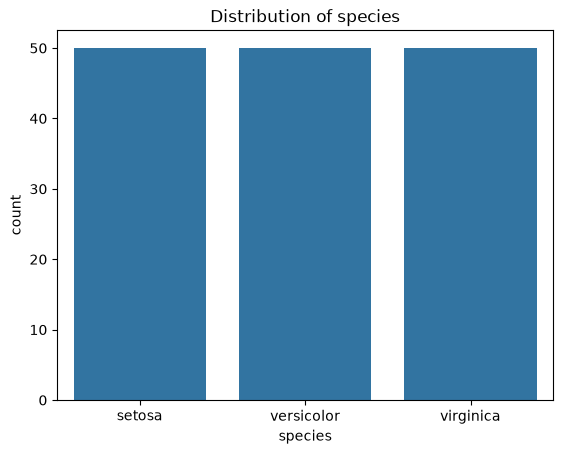

2026-07-19 19:16:50 | INFO | M03 | Feature columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
2026-07-19 19:16:50 | INFO | M03 | Feature data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
dtype: object


In [34]:
# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "Iris"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# CUSTOM: ANALYST CHOICE - the categorical target to classify.
TARGET_COL: Final[str] = "species"

# View list of columns in the dataset
LOG.info(f"Columns in dataset: {df.columns.tolist()}")

# CUSTOM: Numeric features used to predict the target.
FEATURE_COLS: Final[list[str]] = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

# Visualize the distribution of the target variable
sns.countplot(data=df_model, x=TARGET_COL)
plt.title(f"Distribution of {TARGET_COL}")
plt.show()

# List the feature columns and their data types
LOG.info(f"Feature columns: {FEATURE_COLS}")
LOG.info(f"Feature data types:\n{df_model[FEATURE_COLS].dtypes}")

# Pair features into subsets to determine how changing the number and type of input features affects the target
# affect model performance.
FEATURE_COLS_1: Final[list[str]] = [
    "sepal_length",
    "sepal_width",
]

FEATURE_COLS_2: Final[list[str]] = [
    "petal_length",
    "petal_width",
]

FEATURE_COLS_3: Final[list[str]] = [
    "sepal_length",
    "petal_length",
]

FEATURE_COLS_4: Final[list[str]] = [
    "sepal_width",
    "petal_width",
]
FEATURE_COLS_5: Final[list[str]] = [
    "sepal_length",
    "petal_width",
]
FEATURE_COLS_6: Final[list[str]] = [
    "sepal_width",
    "petal_length",
]

FEATURE_COLS_7: Final[list[str]] = [
    "sepal_length",
    "sepal_width",
    "petal_length",
]

FEATURE_COLS_8: Final[list[str]] = [
    "sepal_length",
    "sepal_width",
    "petal_width",
]

FEATURE_COLS_9: Final[list[str]] = [
    "sepal_length",
    "petal_length",
    "petal_width",
]

FEATURE_COLS_10: Final[list[str]] = [
    "sepal_width",
    "petal_length",
    "petal_width",
]

FEATURE_COLS_11: Final[list[str]] = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]

## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.


In [35]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

# Create a set of all feature column combinations for experimentation
FEATURE_SETS: Final[list[list[str]]] = [
    FEATURE_COLS_1,
    FEATURE_COLS_2,
    FEATURE_COLS_3,
    FEATURE_COLS_4,
    FEATURE_COLS_5,
    FEATURE_COLS_6,
    FEATURE_COLS_7,
    FEATURE_COLS_8,
    FEATURE_COLS_9,
    FEATURE_COLS_10,
    FEATURE_COLS_11,
]

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""

y: pd.Series = df_model[TARGET_COL]

for i, feature_cols in enumerate(FEATURE_SETS, start=1):
    name = f"FEATURE_COLS_{i}"
    print(f"\n{name}: {feature_cols}")

    X: pd.DataFrame = df_model[feature_cols]
    LOG.info(f"Processing feature set: {name}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    LOG.info(f"Train instances: {len(X_train)}")
    LOG.info(f"Test instances: {len(X_test)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-19 19:16:50 | INFO | M03 | Processing feature set: FEATURE_COLS_1
2026-07-19 19:16:50 | INFO | M03 | Train instances: 120
2026-07-19 19:16:50 | INFO | M03 | Test instances: 30
2026-07-19 19:16:50 | INFO | M03 | Processing feature set: FEATURE_COLS_2
2026-07-19 19:16:50 | INFO | M03 | Train instances: 120
2026-07-19 19:16:50 | INFO | M03 | Test instances: 30
2026-07-19 19:16:50 | INFO | M03 | Processing feature set: FEATURE_COLS_3
2026-07-19 19:16:50 | INFO | M03 | Train instances: 120
2026-07-19 19:16:50 | INFO | M03 | Test instances: 30
2026-07-19 19:16:50 | INFO | M03 | Processing feature set: FEATURE_COLS_4
2026-07-19 19:16:50 | INFO | M03 | Train instances: 120
2026-07-19 19:16:50 | INFO | M03 | Test instances: 30
2026-07-19 19:16:50 | INFO | M03 | Processing feature set: FEATURE_COLS_5
2026-07-19 19:16:50 | INFO | M03 | Train instances: 120
2026-07-19 19:16:50 | INFO | M03 | Test instances: 30
2026-07-19 19:16:50 | INFO | M03 | Processing feature set: FEATURE_COLS_6
2026-0


FEATURE_COLS_1: ['sepal_length', 'sepal_width']

FEATURE_COLS_2: ['petal_length', 'petal_width']

FEATURE_COLS_3: ['sepal_length', 'petal_length']

FEATURE_COLS_4: ['sepal_width', 'petal_width']

FEATURE_COLS_5: ['sepal_length', 'petal_width']

FEATURE_COLS_6: ['sepal_width', 'petal_length']

FEATURE_COLS_7: ['sepal_length', 'sepal_width', 'petal_length']

FEATURE_COLS_8: ['sepal_length', 'sepal_width', 'petal_width']

FEATURE_COLS_9: ['sepal_length', 'petal_length', 'petal_width']

FEATURE_COLS_10: ['sepal_width', 'petal_length', 'petal_width']

FEATURE_COLS_11: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


## Section 4. Fit a Classifier


ANALYST CHOICE

The model and its parameters are yours to choose. 

This example uses a decision tree with max_depth = MAX_DEPTH. 

Section 6 shows how that choice moves performance; 
here we fit one model and read its scores.


In [36]:
# === Section 4. Fit a Classifier ===


"""
Fit a decision-tree classifier on the training data.

WHY: create -> .fit() -> .predict()
is the same pattern for every scikit-learn estimator.
Learning it once carries to every later model.
"""

# MAX DEPTH is one tunable parameter of the model.

# For a decision tree, max_depth controls complexity:
# - shallow underfits
# - deep overfits

# Section 6 shows the effect; we must choose and defend a value.
# This is typically part of the interative process of model development.
MAX_DEPTH: Final[int] = 3

LOG.info(f"Fitting DecisionTreeClassifier(max_depth={MAX_DEPTH})")

# create a DecisionTreeClassifier with the chosen max_depth and random_state
model = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)

# Normalize FEATURE_SETS so this works whether it's a dict or a list of lists.
feature_map: dict[str, list[str]] = (
    FEATURE_SETS
    if isinstance(FEATURE_SETS, dict)
    else {f"FEATURE_COLS_{i}": cols for i, cols in enumerate(FEATURE_SETS, start=1)}
)

results: list[dict[str, object]] = []
y = df_model[TARGET_COL]

for name, feature_cols in feature_map.items():
    X = df_model[feature_cols]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    model = DecisionTreeClassifier(
        max_depth=MAX_DEPTH,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)

    results.append(
        {
            "Feature Set": name,
            "Features": ", ".join(feature_cols),
            "No. Features": len(feature_cols),
            "Train Accuracy": model.score(X_train, y_train),
            "Test Accuracy": model.score(X_test, y_test),
        }
    )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Test Accuracy", ascending=False)

LOG.info(f"\n{results_df}")

2026-07-19 19:16:50 | INFO | M03 | Fitting DecisionTreeClassifier(max_depth=3)
2026-07-19 19:16:51 | INFO | M03 | 
        Feature Set                                           Features  No. Features  Train Accuracy  Test Accuracy
1    FEATURE_COLS_2                          petal_length, petal_width             2        0.983333       0.966667
10  FEATURE_COLS_11  sepal_length, sepal_width, petal_length, petal...             4        0.983333       0.966667
9   FEATURE_COLS_10             sepal_width, petal_length, petal_width             3        0.983333       0.966667
8    FEATURE_COLS_9            sepal_length, petal_length, petal_width             3        0.983333       0.966667
7    FEATURE_COLS_8             sepal_length, sepal_width, petal_width             3        0.975000       0.933333
4    FEATURE_COLS_5                          sepal_length, petal_width             2        0.975000       0.933333
3    FEATURE_COLS_4                           sepal_width, petal_width   

## Section 5. Evaluate the Model

2026-07-19 19:16:51 | INFO | M03 | Test accuracy: 0.967
2026-07-19 19:16:51 | INFO | M03 | Per-class precision / recall / F1:
2026-07-19 19:16:51 | DEBUG | M03 | 
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

2026-07-19 19:16:51 | INFO | M03 | Showing confusion matrix (rows = actual, cols = predicted)


<Figure size 640x480 with 0 Axes>

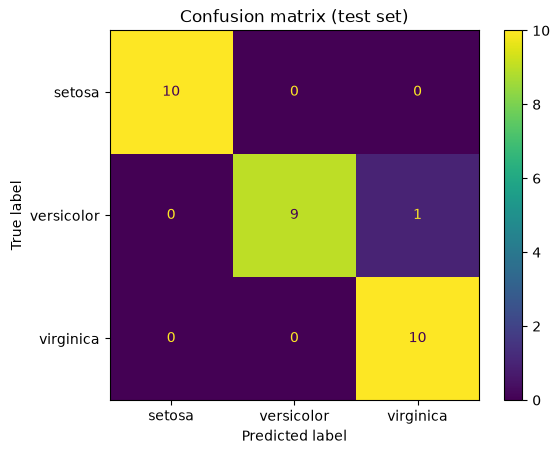

In [37]:
# === Section 5. Evaluate the Model ===

"""Score the model on held-out data and show a confusion matrix.

WHY: A single accuracy number hides which classes get confused.
The report adds precision/recall/F1 per class;
the confusion matrix shows the actual vs. predicted counts.
Read them together.

Code only reports numbers.

It does NOT declare the model good enough.
Whether a model is good enough depends on what a mistake costs
in this specific problem,
which requires analyst judgment.
"""

y_pred: np.ndarray = model.predict(X_test)

# The built in sklearn accuracy_score() function
# returns a numpy Float,
# which is not the same as a native Python float.
# call float() to convert it to a native Python float for better compatibility with other code and libraries.
test_acc: float = float(accuracy_score(y_test, y_pred))
LOG.info(f"Test accuracy: {test_acc:.3f}")

LOG.info("Per-class precision / recall / F1:")
LOG.debug(f"\n{classification_report(y_test, y_pred)}")

LOG.info("Showing confusion matrix (rows = actual, cols = predicted)")

# start a figure
plt.figure()

# create the confusion matrix display
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

# set the title
plt.title("Confusion matrix (test set)")

# show the plot
plt.show()

## Section 6. Parameter Selection Affects Performance

We **sweep** `max_depth`.

We try every value in a range and plot 
accuracy on **train** vs **test** for each one.

Choose a range that starts low (1–2) and 
goes high enough to see the train score 
plateau near 1.0 
while the test score levels off or drops. 

How high that is depends on the dataset.
More features and more complex patterns 
need deeper trees to overfit. 
Start wide and narrow in.

The shape is the lesson:

- very shallow trees **underfit** (both scores low)
- very deep trees **overfit** (train near 1.0, test drops or flattens)

The best depth is where test accuracy is strong 
and the train/test gap is small. 

Finding that is the job of the analyst.

In [38]:
# Define all independent feature combinations that will be evaluated.
FEATURE_SETS = {
    "FEATURE_COLS_1": FEATURE_COLS_1,
    "FEATURE_COLS_2": FEATURE_COLS_2,
    "FEATURE_COLS_3": FEATURE_COLS_3,
    "FEATURE_COLS_4": FEATURE_COLS_4,
    "FEATURE_COLS_5": FEATURE_COLS_5,
    "FEATURE_COLS_6": FEATURE_COLS_6,
    "FEATURE_COLS_7": FEATURE_COLS_7,
    "FEATURE_COLS_8": FEATURE_COLS_8,
    "FEATURE_COLS_9": FEATURE_COLS_9,
    "FEATURE_COLS_10": FEATURE_COLS_10,
}

# Define the maximum tree depth to test.
# Smaller values can underfit; larger values can overfit.
MAX_SWEEP: Final[int] = 12

# Store model performance results for every feature set and depth.
results: list[dict[str, object]] = []


# Evaluate each independent feature combination.
for feature_name, feature_cols in FEATURE_SETS.items():
    # Select the current feature columns.
    X = df_model[feature_cols]

    # Select the target variable.
    y = df_model[TARGET_COL]

    # Split data into training and testing sets.
    # Stratify preserves the class distribution in both sets.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    # Test different decision tree depths.
    for depth in range(1, MAX_SWEEP + 1):
        # Create a decision tree with the current max_depth.
        model = DecisionTreeClassifier(
            max_depth=depth,
            random_state=RANDOM_STATE,
        )

        # Train the model.
        model.fit(X_train, y_train)

        # Generate predictions for accuracy calculation.
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Store results for this feature set and depth.
        results.append(
            {
                "Feature Set": feature_name,
                "Features": ", ".join(feature_cols),
                "Max Depth": depth,
                # Accuracy = correctly classified samples / total samples.
                "Train Accuracy": accuracy_score(y_train, y_train_pred),
                "Test Accuracy": accuracy_score(y_test, y_test_pred),
            }
        )


# Convert results into a DataFrame for comparison.
results_df = pd.DataFrame(results)


# Rank models from highest to lowest test accuracy.
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)


# Display the best-performing combinations.
LOG.info(results_df.head(10))

2026-07-19 19:16:52 | INFO | M03 |          Feature Set                                 Features  Max Depth  Train Accuracy  Test Accuracy
14    FEATURE_COLS_2                petal_length, petal_width          3        0.983333       0.966667
110  FEATURE_COLS_10   sepal_width, petal_length, petal_width          3        0.983333       0.966667
111  FEATURE_COLS_10   sepal_width, petal_length, petal_width          4        0.991667       0.966667
115  FEATURE_COLS_10   sepal_width, petal_length, petal_width          8        1.000000       0.966667
116  FEATURE_COLS_10   sepal_width, petal_length, petal_width          9        1.000000       0.966667
117  FEATURE_COLS_10   sepal_width, petal_length, petal_width         10        1.000000       0.966667
119  FEATURE_COLS_10   sepal_width, petal_length, petal_width         12        1.000000       0.966667
118  FEATURE_COLS_10   sepal_width, petal_length, petal_width         11        1.000000       0.966667
112  FEATURE_COLS_10   sepal_

2026-07-19 19:16:52 | DEBUG | M03 |   depth= 1  train=0.667  test=0.667


2026-07-19 19:16:52 | DEBUG | M03 |   depth= 2  train=0.967  test=0.933
2026-07-19 19:16:52 | DEBUG | M03 |   depth= 3  train=0.983  test=0.967
2026-07-19 19:16:52 | DEBUG | M03 |   depth= 4  train=0.992  test=0.967
2026-07-19 19:16:52 | DEBUG | M03 |   depth= 5  train=1.000  test=0.967
2026-07-19 19:16:52 | DEBUG | M03 |   depth= 6  train=1.000  test=0.967
2026-07-19 19:16:52 | DEBUG | M03 |   depth= 7  train=1.000  test=0.967
2026-07-19 19:16:52 | DEBUG | M03 |   depth= 8  train=1.000  test=0.967
2026-07-19 19:16:52 | DEBUG | M03 |   depth= 9  train=1.000  test=0.967
2026-07-19 19:16:52 | DEBUG | M03 |   depth=10  train=1.000  test=0.967
2026-07-19 19:16:52 | DEBUG | M03 |   depth=11  train=1.000  test=0.967
2026-07-19 19:16:52 | DEBUG | M03 |   depth=12  train=1.000  test=0.967


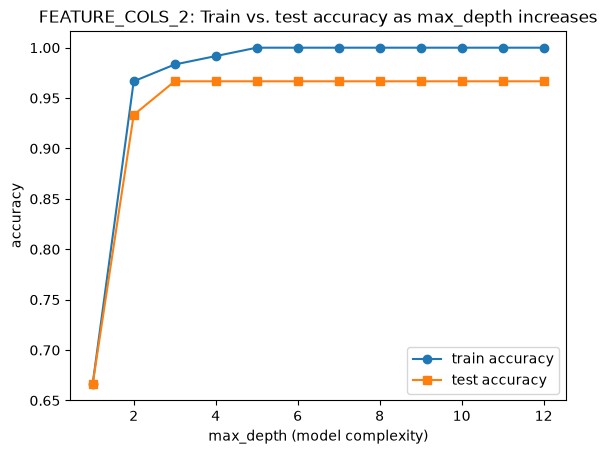

In [39]:
# === Section 6. How Parameter Selection Affects Performance ===

# CUSTOM: ANALYST CHOICE
# for penquins, sweep from 1 to 12 as a good range.
# THIS IS DATA SET DEPENDENT and ANALYST CHOICE.

MAX_SWEEP: Final[int] = 12

# Declare lists to hold the depths and corresponding train/test scores.
depths: list[int] = list(range(1, MAX_SWEEP + 1))
train_scores: list[float] = []
test_scores: list[float] = []

for depth in depths:
    # create and fit a DecisionTreeClassifier with the current depth and random_state
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)

    acc_score_train = accuracy_score(y_train, m.predict(X_train))
    acc_score_test = accuracy_score(y_test, m.predict(X_test))

    # Use float() to convert from numpy Float to native Python float for better compatibility with other code and libraries.
    train_scores.append(float(acc_score_train))
    test_scores.append(float(acc_score_test))

    LOG.debug(
        f"  depth={depth:2d}  train={train_scores[-1]:.3f}  test={test_scores[-1]:.3f}"
    )

# start a new figure
plt.figure()

# plot the train and test scores against the depths
plt.plot(depths, train_scores, marker="o", label="train accuracy")
plt.plot(depths, test_scores, marker="s", label="test accuracy")

# label the axes and add a title and legend
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.title("FEATURE_COLS_2: Train vs. test accuracy as max_depth increases")
plt.legend()

# show the plot
plt.show()

### Interpretation
 
 The  best model according to this analysis and performance score is a decision tree model using independent features  petal_length and petal_width with depth 3 which has train accuracy score of 0.983333 and test accuracy score of       0.966667. We can notice from the graph above the depths before the 3 causes underfitting and depths over 3 causes overfitting.

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [40]:
# === Python Summary ===

"""Record what was fit and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:   {DATASET_NAME}")
LOG.info(f"Target:    {TARGET_COL}  (classification)")
LOG.info(f"Features:  {FEATURE_COLS}")
LOG.info(f"Model:     DecisionTreeClassifier(max_depth={MAX_DEPTH})")
LOG.info("========================")

2026-07-19 19:16:52 | INFO | M03 | ========================
2026-07-19 19:16:52 | INFO | M03 | SUMMARY
2026-07-19 19:16:52 | INFO | M03 | ========================
2026-07-19 19:16:52 | INFO | M03 | Dataset:   Iris
2026-07-19 19:16:52 | INFO | M03 | Target:    species  (classification)
2026-07-19 19:16:52 | INFO | M03 | Features:  ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
2026-07-19 19:16:52 | INFO | M03 | Model:     DecisionTreeClassifier(max_depth=3)
2026-07-19 19:16:52 | INFO | M03 | ========================
